# Import


In [1]:
!pip install gdown
!pip install xgboost

In [2]:
import gdown
import pandas as pd
import numpy as np
from pathlib import Path
from google.colab import drive
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
import re
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import learning_curve
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.metrics import cohen_kappa_score
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import StratifiedKFold
from collections import Counter
from sklearn.metrics import mean_absolute_error, mean_squared_error
from scipy.stats import spearmanr
from IPython.display import display, HTML
from sklearn.metrics import make_scorer

#Load the data

In [3]:
file_id = "16DpeNAU5f9J8n6tR1kKAS9tWtqKkKPID"
url = f"https://drive.google.com/uc?id={file_id}"
output = "Essays.csv"

gdown.download(url, output, quiet=False)

# !unzip -q ML-MP1-rawdata.zip -d ./ML-MP1-rawdata


Downloading...
From: https://drive.google.com/uc?id=16DpeNAU5f9J8n6tR1kKAS9tWtqKkKPID
To: /content/Essays.csv
100%|██████████| 36.2M/36.2M [00:00<00:00, 101MB/s] 


'Essays.csv'

In [4]:
df = pd.read_csv(output)
print(df.info())
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17307 entries, 0 to 17306
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   essay_id   17307 non-null  object
 1   full_text  17307 non-null  object
 2   score      17307 non-null  int64 
dtypes: int64(1), object(2)
memory usage: 405.8+ KB
None


,essay_id,full_text,score
0,000d118,Many people have car where they live. The thin...,3
1,000fe60,I am a scientist at NASA that is discussing th...,3
2,001ab80,People always wish they had the same technolog...,4
3,001bdc0,"We all heard about Venus, the planet without a...",4
4,002ba53,"Dear, State Senator\n\nThis is a letter to arg...",3


In [5]:
df["essay_id"] = df["essay_id"].astype(str)
df["full_text"] = df["full_text"].astype(str)
df["score"] = df["score"].astype(int)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17307 entries, 0 to 17306
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   essay_id   17307 non-null  object
 1   full_text  17307 non-null  object
 2   score      17307 non-null  int64 
dtypes: int64(1), object(2)
memory usage: 405.8+ KB


#EDA and Data Split

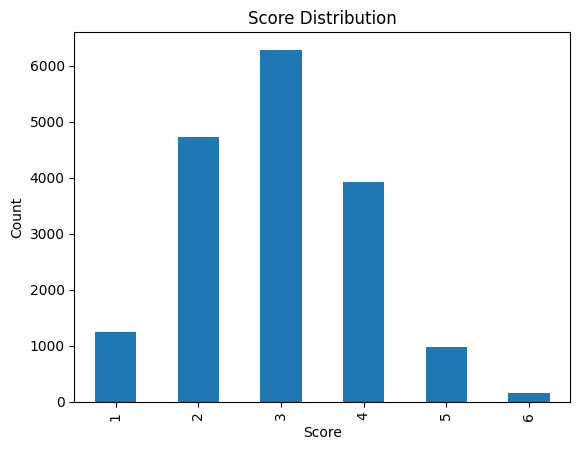

In [6]:
plt.figure()
df["score"].value_counts().sort_index().plot(kind="bar")
plt.title("Score Distribution")
plt.xlabel("Score")
plt.ylabel("Count")
plt.show()

In [7]:
df["word_count"] = df["full_text"].apply(lambda x: len(x.split()))


def letter_count(text):
    letters_only = re.sub(r"[^A-Za-z]", "", text)
    return len(letters_only)

df["letter_count"] = df["full_text"].apply(letter_count)
df["avg_word_length"] = df["letter_count"] / df["word_count"]

df["avg_word_length"].describe()

,avg_word_length
count,17307.000000
mean,4.405679
std,0.296543
min,3.355805
25%,4.199324
50%,4.401408
75%,4.611534
max,5.604396


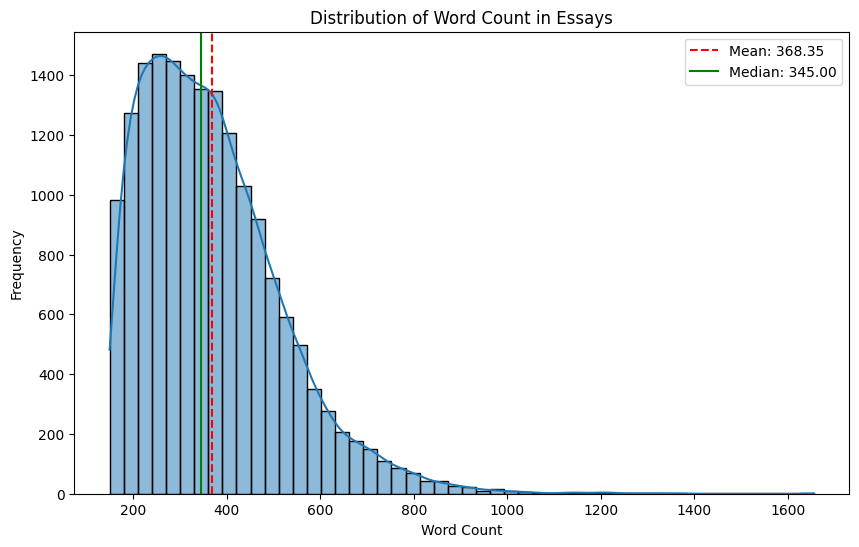

In [8]:
plt.figure(figsize=(10, 6))
sns.histplot(df['word_count'], bins=50, kde=True)

mean_word_count = df['word_count'].mean()
median_word_count = df['word_count'].median()

plt.axvline(mean_word_count, color='red', linestyle='--', label=f'Mean: {mean_word_count:.2f}')
plt.axvline(median_word_count, color='green', linestyle='-', label=f'Median: {median_word_count:.2f}')

plt.title('Distribution of Word Count in Essays')
plt.xlabel('Word Count')
plt.ylabel('Frequency')
plt.legend()
plt.show()

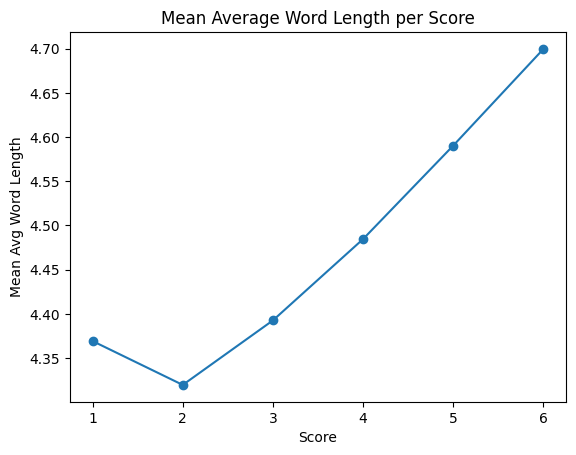

In [9]:
mean_word_len = df.groupby("score")["avg_word_length"].mean()

plt.figure()
plt.plot(mean_word_len.index, mean_word_len.values, marker="o")
plt.title("Mean Average Word Length per Score")
plt.xlabel("Score")
plt.ylabel("Mean Avg Word Length")
plt.show()

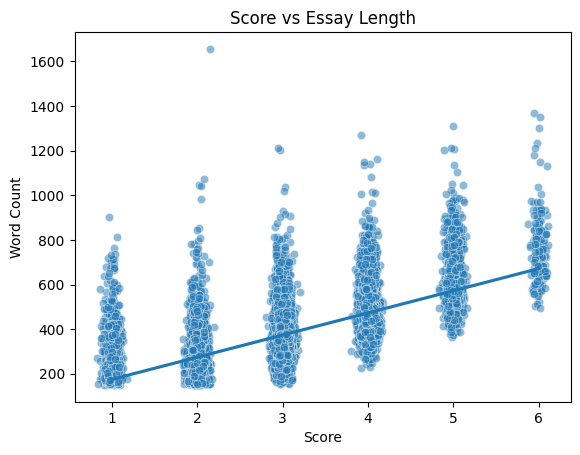

In [10]:
plt.figure()

jitter = np.random.normal(0, 0.05, size=len(df))
sns.scatterplot(
    x=df["score"] + jitter,
    y=df["word_count"],
    alpha=0.5
)

sns.regplot(
    x="score",
    y="word_count",
    data=df,
    scatter=False,
    ci=None
)

plt.title("Score vs Essay Length")
plt.xlabel("Score")
plt.ylabel("Word Count")
plt.show()

In [11]:
print("Duplicate essays:", df["full_text"].duplicated().sum())

Duplicate essays: 0


In [12]:
X = df["full_text"]
y = df["score"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

print("Train size:", X_train.shape[0])
print("Test size:", X_test.shape[0])


Train size: 13845
Test size: 3462


# Classical ML Baselines (Feature-Based)

In [13]:
def quadratic_weighted_kappa(y_true, y_pred):
    y_pred = np.round(y_pred).astype(int)
    return cohen_kappa_score(y_true, y_pred, weights="quadratic")

In [14]:
class LengthFeatures(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        return self

    def transform(self, X):
        word_count = X.str.split().apply(len)
        char_count = X.apply(letter_count)
        avg_word_len = char_count / word_count
        unique_word_count = X.apply(lambda text: len(set(text.lower().split())))

        return np.vstack([word_count, avg_word_len, unique_word_count]).T

In [16]:
X_train_df = X_train.to_frame(name="full_text")
X_test_df = X_test.to_frame(name="full_text")

qwk_scorer = make_scorer(quadratic_weighted_kappa)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_scores = []

Starting Feature Ablation Experiment...

--- Running Baseline Model (Ridge) ---
Baseline (Full Ridge Model) Mean CV QWK: 0.6933

--- Running Model without word_tfidf ---
Mean CV QWK without word_tfidf: 0.5343

--- Running Model without char_tfidf ---
Mean CV QWK without char_tfidf: 0.6312

--- Running Model without length_features ---
Mean CV QWK without length_features: 0.6816

Feature Ablation Experiment Complete.
Ablation Results: {'Full Model': np.float64(0.6932777699102459), 'No Word Tfidf': np.float64(0.5343014797089696), 'No Char Tfidf': np.float64(0.6311575660790242), 'No Length Features': np.float64(0.6816020830313629)}


/tmp/ipython-input-3047/783811456.py:87: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(ablation_results.keys()), y=list(ablation_results.values()), palette="rocket")


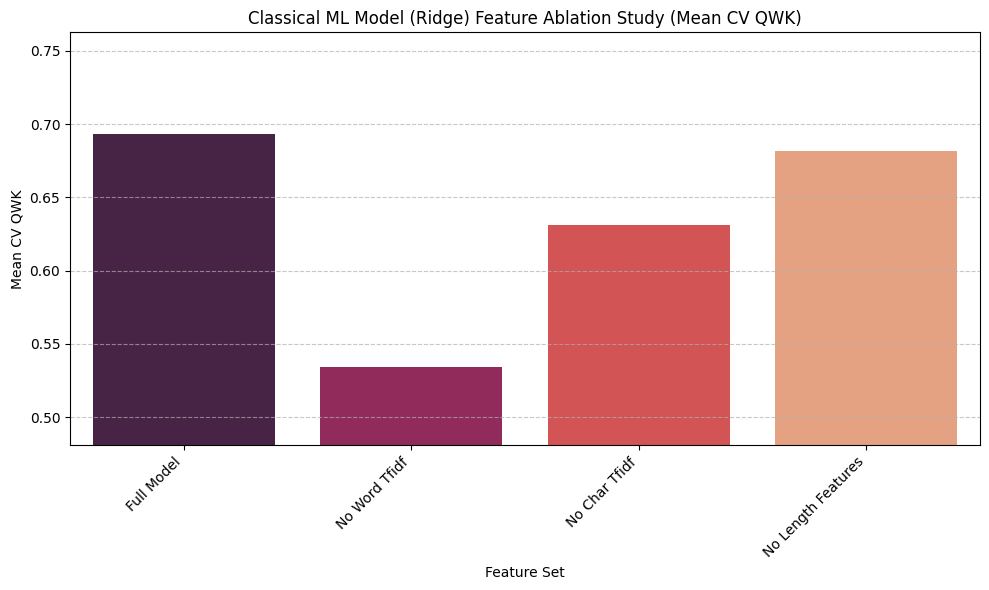

In [18]:
print("Starting Feature Ablation Experiment...")

# Helper function to create an ablated preprocessor
def create_ablated_preprocessor(exclude_feature=None):
    transformers_config = [
        ("word_tfidf",
         TfidfVectorizer(ngram_range=(1,2),
                         max_features=50000,
                         stop_words="english"),
         "full_text"),

        ("char_tfidf",
         TfidfVectorizer(analyzer="char",
                         ngram_range=(3,5),
                         max_features=30000),
         "full_text"),

        ("length_features",
         LengthFeatures(),
         "full_text")
    ]

    if exclude_feature:
        transformers_config = [t for t in transformers_config if t[0] != exclude_feature]

    return ColumnTransformer(transformers=transformers_config, remainder='passthrough')


ablation_results = {}

# --- Baseline: Full Model (Ridge as per task request) ---
print("\n--- Running Baseline Model (Ridge) ---")
full_preprocessor = create_ablated_preprocessor() # All features
full_model_ridge = Pipeline([
    ("features", full_preprocessor),
    ("scaler", StandardScaler(with_mean=False)),
    ("regressor", Ridge(alpha=1)) # Use Ridge as requested for ablation
])

skf_ablation = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores_baseline = []
for fold, (train_idx, val_idx) in enumerate(skf_ablation.split(X_train_df, y_train)):
    X_tr = X_train_df.iloc[train_idx]
    y_tr = y_train.iloc[train_idx]
    X_val = X_train_df.iloc[val_idx]
    y_val = y_train.iloc[val_idx]
    full_model_ridge.fit(X_tr, y_tr)
    preds = full_model_ridge.predict(X_val)
    score = quadratic_weighted_kappa(y_val, preds)
    cv_scores_baseline.append(score)
print(f"Baseline (Full Ridge Model) Mean CV QWK: {np.mean(cv_scores_baseline):.4f}")
ablation_results["Full Model"] = np.mean(cv_scores_baseline)


# --- Ablation: Remove each feature set ---
feature_sets_to_ablate = ["word_tfidf", "char_tfidf", "length_features"]

for feature_to_remove in feature_sets_to_ablate:
    print(f"\n--- Running Model without {feature_to_remove} ---")
    ablated_preprocessor = create_ablated_preprocessor(exclude_feature=feature_to_remove)
    ablated_model = Pipeline([
        ("features", ablated_preprocessor),
        ("scaler", StandardScaler(with_mean=False)),
        ("regressor", Ridge(alpha=1))
    ])

    cv_scores_ablated = []
    for fold, (train_idx, val_idx) in enumerate(skf_ablation.split(X_train_df, y_train)):
        X_tr = X_train_df.iloc[train_idx]
        y_tr = y_train.iloc[train_idx]
        X_val = X_train_df.iloc[val_idx]
        y_val = y_train.iloc[val_idx]
        ablated_model.fit(X_tr, y_tr)
        preds = ablated_model.predict(X_val)
        score = quadratic_weighted_kappa(y_val, preds)
        cv_scores_ablated.append(score)

    mean_qwk_ablated = np.mean(cv_scores_ablated)
    print(f"Mean CV QWK without {feature_to_remove}: {mean_qwk_ablated:.4f}")
    ablation_results[f"No {feature_to_remove.replace('_', ' ').title()}"] = mean_qwk_ablated

print("\nFeature Ablation Experiment Complete.")
print("Ablation Results:", ablation_results)

# --- Plotting Results ---
plt.figure(figsize=(10, 6))
sns.barplot(x=list(ablation_results.keys()), y=list(ablation_results.values()), palette="rocket")
plt.title("Classical ML Model (Ridge) Feature Ablation Study (Mean CV QWK)")
plt.xlabel("Feature Set")
plt.ylabel("Mean CV QWK")
plt.ylim(min(ablation_results.values()) * 0.9, max(ablation_results.values()) * 1.1) # Adjust y-axis for better visual
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Top 20 most important features (absolute coefficient value):


,feature,coefficient,abs_coefficient
80000,word_count,0.039319,0.039319
80002,unique_word_count,0.028241,0.028241
41543,supports author,0.009191,0.009191
8472,college members,0.006620,0.006620
14271,elections electoral,0.006516,0.006516
26383,machines longer,0.006181,0.006181
28179,monument april,-0.005946,0.005946
2865,atmosphere importantly,-0.005819,0.005819
52579,the,0.005693,0.005693
41457,sun long,-0.005681,0.005681


/tmp/ipython-input-3047/41370588.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='coefficient', y='feature', data=top_positive_coefs, palette='viridis')
/tmp/ipython-input-3047/41370588.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='coefficient', y='feature', data=top_negative_coefs, palette='magma')


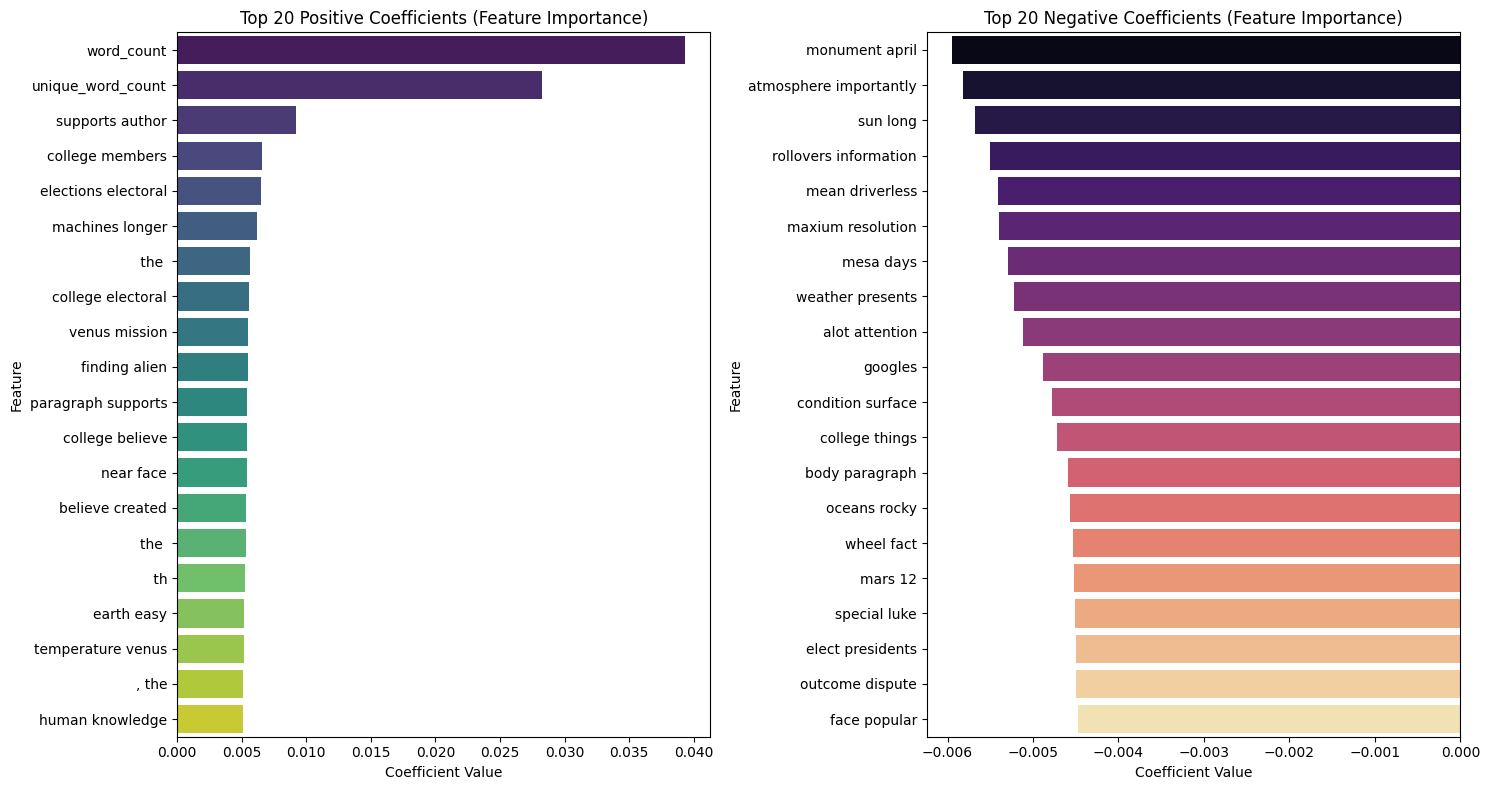

Coefficient analysis and plotting complete.


In [19]:
ridge_regressor = full_model_ridge.named_steps['regressor'] # Using full_model_ridge from ablation study
coefficients = ridge_regressor.coef_

preprocessor = full_model_ridge.named_steps['features']

word_tfidf_feature_names = preprocessor.named_transformers_['word_tfidf'].get_feature_names_out()
char_tfidf_feature_names = preprocessor.named_transformers_['char_tfidf'].get_feature_names_out()
length_feature_names = ['word_count', 'avg_word_length', 'unique_word_count']

# Combine all feature names in the correct order
all_feature_names = np.concatenate([
    word_tfidf_feature_names,
    char_tfidf_feature_names,
    length_feature_names
])

coef_df = pd.DataFrame({'feature': all_feature_names, 'coefficient': coefficients})
coef_df['abs_coefficient'] = np.abs(coef_df['coefficient'])
coef_df = coef_df.sort_values(by='abs_coefficient', ascending=False)

print("Top 20 most important features (absolute coefficient value):")
display(coef_df.head(20))

TOP_N = 20
top_positive_coefs = coef_df.sort_values(by='coefficient', ascending=False).head(TOP_N)
top_negative_coefs = coef_df.sort_values(by='coefficient', ascending=True).head(TOP_N)

plt.figure(figsize=(15, 8))

plt.subplot(1, 2, 1)
sns.barplot(x='coefficient', y='feature', data=top_positive_coefs, palette='viridis')
plt.title(f'Top {TOP_N} Positive Coefficients (Feature Importance)')
plt.xlabel('Coefficient Value')
plt.ylabel('Feature')

plt.subplot(1, 2, 2)
sns.barplot(x='coefficient', y='feature', data=top_negative_coefs, palette='magma')
plt.title(f'Top {TOP_N} Negative Coefficients (Feature Importance)')
plt.xlabel('Coefficient Value')
plt.ylabel('Feature')

plt.tight_layout()
plt.show()

print("Coefficient analysis and plotting complete.")

## Main Train and Test

In [21]:
full_model_ridge.fit(X_train_df, y_train)

Pipeline(steps=[('features',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('word_tfidf',
                                                  TfidfVectorizer(max_features=50000,
                                                                  ngram_range=(1,
                                                                               2),
                                                                  stop_words='english'),
                                                  'full_text'),
                                                 ('char_tfidf',
                                                  TfidfVectorizer(analyzer='char',
                                                                  max_features=30000,
                                                                  ngram_range=(3,
                                                                               5)),
                                                  'full_text'),
                                                 ('length_features',
                                                  LengthFeatures(),
                                                  'full_text')])),
                ('scaler', StandardScaler(with_mean=False)),
                ('regressor', Ridge(alpha=1))])

In [22]:
test_preds = full_model_ridge.predict(X_test_df)

test_qwk = quadratic_weighted_kappa(y_test, test_preds)

mae = mean_absolute_error(y_test, test_preds)
rmse = np.sqrt(mean_squared_error(y_test, test_preds))
spearman_corr = spearmanr(y_test, test_preds).correlation

print("\nTest Results:")
print("QWK:", test_qwk)
print("MAE:", mae)
print("RMSE:", rmse)
print("Spearman:", spearman_corr)


Test Results:
QWK: 0.6963777095776731
MAE: 0.5763655073009382
RMSE: 0.7194022333990402
Spearman: 0.720278682766547


# BiLSTM

In [23]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [24]:
def tokenize(text):
    return text.lower().split()

In [25]:
def build_vocab(texts, max_vocab=20000):
    counter = Counter()
    for text in texts:
        counter.update(tokenize(text))

    most_common = counter.most_common(max_vocab - 2)

    vocab = {"<PAD>": 0, "<UNK>": 1}
    for i, (word, _) in enumerate(most_common, start=2):
        vocab[word] = i

    return vocab

vocab = build_vocab(X_train)
vocab_size = len(vocab)

According to [the distribution of word count in essays](https://colab.research.google.com/drive/15wc8SsyFYgDYL8iRgHMda0Rv9AOPjjNp#scrollTo=irBh4mmJUmYW&line=3&uniqifier=1) that was plotted earlier, mean was 368.35.

Then I picked MAX_LEN = 400 as the first try and then changed it to 500, which improved the results.

In [26]:
MAX_LEN = 500
DROPOUT=0.3
HIDDEN_DIM = 128
EMBEDDING_DIM=100
LEARNING_RATE=1e-3

def encode(text, vocab):
    tokens = tokenize(text)
    ids = [vocab.get(t, vocab["<UNK>"]) for t in tokens]
    return ids[:MAX_LEN]

class EssayDataset(Dataset):
    def __init__(self, texts, labels, vocab):
        self.texts = texts.values
        self.labels = labels.values
        self.vocab = vocab

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoded = encode(self.texts[idx], self.vocab)
        label = self.labels[idx]
        return torch.tensor(encoded), torch.tensor(label, dtype=torch.float32)

In [27]:
def collate_fn(batch):
    texts, labels = zip(*batch)
    lengths = [len(t) for t in texts]
    max_len = max(lengths)

    padded = []
    for t in texts:
        pad_size = max_len - len(t)
        padded.append(torch.cat([t, torch.zeros(pad_size, dtype=torch.long)]))

    return torch.stack(padded), torch.tensor(labels)

In [28]:
class Attention(nn.Module):
    def __init__(self, hidden_dim):
        super().__init__()
        self.attn = nn.Linear(hidden_dim * 2, 1)

    def forward(self, lstm_output):
        # lstm_output: (batch, seq_len, hidden*2)
        weights = torch.softmax(self.attn(lstm_output), dim=1)
        weighted = lstm_output * weights
        return weights, weighted.sum(dim=1)

In [29]:
class BiLSTMModel(nn.Module):
    def __init__(self, vocab_size, embed_dim=EMBEDDING_DIM, hidden_dim=HIDDEN_DIM):
        super().__init__()

        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)

        self.lstm = nn.LSTM(
            embed_dim,
            hidden_dim,
            batch_first=True,
            bidirectional=True
        )

        self.attention = Attention(hidden_dim)
        self.dropout = nn.Dropout(DROPOUT)
        self.fc = nn.Linear(hidden_dim * 2, 1)

    def forward(self, x):
        x = self.embedding(x)
        lstm_out, _ = self.lstm(x)

        attention_weights, x = self.attention(lstm_out)

        x = self.dropout(x)
        x = self.fc(x)

        return x.squeeze(1), attention_weights

In [30]:
def quadratic_weighted_kappa(y_true, y_pred):
    y_pred = np.round(y_pred).astype(int)
    return cohen_kappa_score(y_true, y_pred, weights="quadratic")

In [31]:
def train_model(model, train_loader, val_loader, epochs=15, patience=2):

    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    criterion = nn.MSELoss()

    best_qwk = -1
    patience_counter = 0

    for epoch in range(epochs):

        # -------- TRAINING --------
        model.train()
        for texts, labels in train_loader:

            texts = texts.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()
            outputs, _ = model(texts) # Unpack outputs, ignore attention weights for training
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

        # -------- VALIDATION --------
        model.eval()
        all_preds = []
        all_labels = []

        with torch.no_grad():
            for texts, labels in val_loader:

                texts = texts.to(device)
                labels = labels.to(device)

                outputs, _ = model(texts) # Unpack outputs, ignore attention weights for validation

                all_preds.extend(outputs.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())

        qwk = quadratic_weighted_kappa(
            np.array(all_labels),
            np.array(all_preds)
        )

        print(f"Epoch {epoch+1} - Val QWK: {qwk:.4f}")

        # -------- EARLY STOPPING --------
        if qwk > best_qwk:
            best_qwk = qwk
            patience_counter = 0
            best_model_state = model.state_dict()
        else:
            patience_counter += 1

            if patience_counter >= patience:
                print("Early stopping triggered.")
                break

    # Load best model
    model.load_state_dict(best_model_state)

    return best_qwk

In [32]:
def run_cross_validation(
    X_data,
    y_data,
    vocab,
    vocab_size,
    n_splits=5
):
    skf = StratifiedKFold(
        n_splits=n_splits,
        shuffle=True,
        random_state=42
    )

    cv_scores = []

    for fold, (train_idx, val_idx) in enumerate(skf.split(X_data, y_data)):
        print(f"\nFold {fold+1}")

        X_tr = X_data.iloc[train_idx]
        y_tr = y_data.iloc[train_idx]

        X_val = X_data.iloc[val_idx]
        y_val = y_data.iloc[val_idx]

        train_dataset = EssayDataset(X_tr, y_tr, vocab)
        val_dataset = EssayDataset(X_val, y_val, vocab)

        train_loader = DataLoader(
            train_dataset,
            batch_size=32,
            shuffle=True,
            collate_fn=collate_fn
        )

        val_loader = DataLoader(
            val_dataset,
            batch_size=32,
            collate_fn=collate_fn
        )

        model = BiLSTMModel(vocab_size).to(device)

        score = train_model(model, train_loader, val_loader)

        cv_scores.append(score)
        print(f"Fold {fold+1} QWK: {score:.4f}")

    mean_score = np.mean(cv_scores)
    print("\nMean CV QWK:", mean_score)

    return mean_score, cv_scores

In [33]:
mean_bilstm_qwk, bilstm_cv_scores = run_cross_validation(X_train, y_train, vocab, vocab_size)


Fold 1
Epoch 1 - Val QWK: 0.6941
Epoch 2 - Val QWK: 0.6645
Epoch 3 - Val QWK: 0.7422
Epoch 4 - Val QWK: 0.7412
Epoch 5 - Val QWK: 0.7732
Epoch 6 - Val QWK: 0.7643
Epoch 7 - Val QWK: 0.7646
Early stopping triggered.
Fold 1 QWK: 0.7732

Fold 2
Epoch 1 - Val QWK: 0.6859
Epoch 2 - Val QWK: 0.7277
Epoch 3 - Val QWK: 0.6995
Epoch 4 - Val QWK: 0.7261
Early stopping triggered.
Fold 2 QWK: 0.7277

Fold 3
Epoch 1 - Val QWK: 0.6986
Epoch 2 - Val QWK: 0.7325
Epoch 3 - Val QWK: 0.7604
Epoch 4 - Val QWK: 0.7407
Epoch 5 - Val QWK: 0.7387
Early stopping triggered.
Fold 3 QWK: 0.7604

Fold 4
Epoch 1 - Val QWK: 0.7073
Epoch 2 - Val QWK: 0.7431
Epoch 3 - Val QWK: 0.7488
Epoch 4 - Val QWK: 0.7368
Epoch 5 - Val QWK: 0.7594
Epoch 6 - Val QWK: 0.7605
Epoch 7 - Val QWK: 0.7529
Epoch 8 - Val QWK: 0.7247
Early stopping triggered.
Fold 4 QWK: 0.7605

Fold 5
Epoch 1 - Val QWK: 0.6895
Epoch 2 - Val QWK: 0.7230
Epoch 3 - Val QWK: 0.7262
Epoch 4 - Val QWK: 0.7623
Epoch 5 - Val QWK: 0.7572
Epoch 6 - Val QWK: 0.7516


## Main Train and Test

In [34]:
print("\n========== Training on full training data and evaluating on test set ==========")

full_train_dataset = EssayDataset(X_train, y_train, vocab)
full_train_loader = DataLoader(
    full_train_dataset,
    batch_size=32,
    shuffle=True,
    collate_fn=collate_fn
)

test_dataset = EssayDataset(X_test, y_test, vocab)
test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False, # No need to shuffle test data
    collate_fn=collate_fn
)

final_model = BiLSTMModel(vocab_size).to(device)

print("\nStarting final model training...")
final_best_qwk = train_model(final_model, full_train_loader, test_loader, epochs=15, patience=3)

print(f"\nFinal model training complete. Best Validation QWK: {final_best_qwk:.4f}")

final_model.eval()
all_test_preds = []
all_test_labels = []

with torch.no_grad():
    for texts, labels in test_loader:
        texts = texts.to(device)
        labels = labels.to(device)
        outputs, _ = final_model(texts) # Unpack outputs, ignore attention weights for evaluation
        all_test_preds.extend(outputs.cpu().numpy())
        all_test_labels.extend(labels.cpu().numpy())



========== Training on full training data and evaluating on test set ==========

Starting final model training...
Epoch 1 - Val QWK: 0.6911
Epoch 2 - Val QWK: 0.6970
Epoch 3 - Val QWK: 0.7444
Epoch 4 - Val QWK: 0.7532
Epoch 5 - Val QWK: 0.7614
Epoch 6 - Val QWK: 0.7505
Epoch 7 - Val QWK: 0.7373
Epoch 8 - Val QWK: 0.7340
Early stopping triggered.

Final model training complete. Best Validation QWK: 0.7614


In [35]:
# Calculate metrics for the test set
test_qwk = quadratic_weighted_kappa(np.array(all_test_labels), np.array(all_test_preds))
mae = mean_absolute_error(np.array(all_test_labels), np.array(all_test_preds))
rmse = np.sqrt(mean_squared_error(np.array(all_test_labels), np.array(all_test_preds)))
spearman_corr = spearmanr(np.array(all_test_labels), np.array(all_test_preds)).correlation

print("\n========== Test Set Results ==========")
print(f"Test QWK: {test_qwk:.4f}")
print(f"Test MAE: {mae:.4f}")
print(f"Test RMSE: {rmse:.4f}")
print(f"Test Spearman Correlation: {spearman_corr:.4f}")


========== Test Set Results ==========
Test QWK: 0.7340
Test MAE: 0.5358
Test RMSE: 0.6854
Test Spearman Correlation: 0.7817


## Data-Size Learning Curve

In [36]:
def learning_curve_experiment(
    X_train,
    y_train,
    vocab,
    vocab_size,
    fractions=[0.2, 0.4, 0.6, 0.8],
    n_splits=3
):

    lc_scores = []

    for frac in fractions:
        print(f"\n========== Using {int(frac*100)}% of training data ==========")

        # Stratified subsampling
        X_subset, _, y_subset, _ = train_test_split(
            X_train,
            y_train,
            train_size=frac,
            stratify=y_train,
            random_state=42
        )

        # 🔥 Reuse your CV function
        mean_score, _ = run_cross_validation(
            X_subset,
            y_subset,
            vocab,
            vocab_size,
            n_splits=n_splits
        )

        lc_scores.append(mean_score)

    return fractions, lc_scores

In [37]:
fractions=[0.2, 0.4, 0.6, 0.8]

In [38]:
fractions, lc_scores = learning_curve_experiment(
    X_train,
    y_train,
    vocab,
    vocab_size,
    fractions=fractions,
    n_splits=3
)


========== Using 20% of training data ==========

Fold 1
Epoch 1 - Val QWK: 0.3936
Epoch 2 - Val QWK: 0.6516
Epoch 3 - Val QWK: 0.6512
Epoch 4 - Val QWK: 0.6930
Epoch 5 - Val QWK: 0.7178
Epoch 6 - Val QWK: 0.7224
Epoch 7 - Val QWK: 0.7108
Epoch 8 - Val QWK: 0.6875
Early stopping triggered.
Fold 1 QWK: 0.7224

Fold 2
Epoch 1 - Val QWK: 0.4868
Epoch 2 - Val QWK: 0.6328
Epoch 3 - Val QWK: 0.6423
Epoch 4 - Val QWK: 0.6875
Epoch 5 - Val QWK: 0.6972
Epoch 6 - Val QWK: 0.7141
Epoch 7 - Val QWK: 0.6954
Epoch 8 - Val QWK: 0.6978
Early stopping triggered.
Fold 2 QWK: 0.7141

Fold 3
Epoch 1 - Val QWK: 0.4665
Epoch 2 - Val QWK: 0.6384
Epoch 3 - Val QWK: 0.6575
Epoch 4 - Val QWK: 0.6695
Epoch 5 - Val QWK: 0.6724
Epoch 6 - Val QWK: 0.7084
Epoch 7 - Val QWK: 0.6822
Epoch 8 - Val QWK: 0.7031
Early stopping triggered.
Fold 3 QWK: 0.7084

Mean CV QWK: 0.7149861498365405

========== Using 40% of training data ==========

Fold 1
Epoch 1 - Val QWK: 0.6336
Epoch 2 - Val QWK: 0.6936
Epoch 3 - Val QWK: 0.683

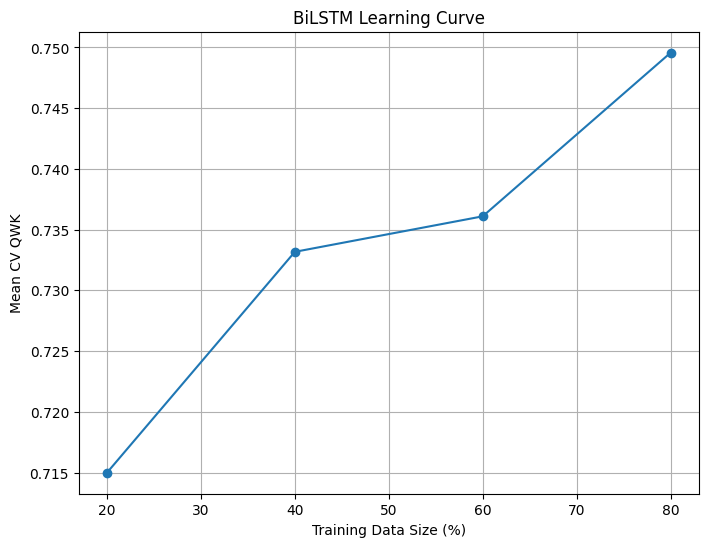

In [39]:
plt.figure(figsize=(8,6))
plt.plot(
    [int(f*100) for f in fractions],
    lc_scores,
    marker='o'
)
plt.xlabel("Training Data Size (%)")
plt.ylabel("Mean CV QWK")
plt.title("BiLSTM Learning Curve")
plt.grid(True)
plt.show()

## Token Attentions

In [40]:
def highlight_attention(text, attention_weights, cmap='Reds'):
    word_tokens = tokenize(text)
    word_tokens_display = word_tokens[:MAX_LEN]
    attention_weights_display = attention_weights[:len(word_tokens_display)]

    if not word_tokens_display or len(attention_weights_display) == 0:
        return ""

    # Normalize weights for coloring (0 to 1)
    norm_weights = (attention_weights_display - attention_weights_display.min()) / (attention_weights_display.max() - attention_weights_display.min() + 1e-9)
    norm_weights = norm_weights.flatten() # Ensure weights are a 1D array of scalars

    html_output = []
    for word, weight in zip(word_tokens_display, norm_weights):
        # Get color from colormap using the new API
        rgba_color = matplotlib.colormaps[cmap](weight)

        # Calculate luminance for dynamic text color
        r, g, b, a = rgba_color
        luminance = (0.299 * r + 0.587 * g + 0.114 * b)
        text_color = 'white' if luminance < 0.5 else 'black'

        # Convert RGBA to hex for HTML background
        hex_color = '#%02x%02x%02x' % (int(r*255), int(g*255), int(b*255))
        html_output.append(f'<span style="background-color: {hex_color}; color: {text_color};">{word}</span>')
    return ' '.join(html_output)

# Select 5 random essays from the test set
random_indices = np.random.choice(len(X_test), 5, replace=False)
random_essays_X = X_test.iloc[random_indices]
random_essays_y = y_test.iloc[random_indices]

print("\nVisualizing Token Attention for 5 Random Essays:")
for i, (idx, essay_text) in enumerate(random_essays_X.items()):
    true_score = random_essays_y.loc[idx]

    # Prepare input for the model
    encoded_essay = encode(essay_text, vocab)
    input_tensor = torch.tensor([encoded_essay], dtype=torch.long).to(device)

    # Get predictions and attention weights
    final_model.eval()
    with torch.no_grad():
        pred_score, attn_weights = final_model(input_tensor)

    pred_score = pred_score.cpu().item()
    attn_weights = attn_weights.squeeze(0).cpu().numpy()

    print(f"\n--- Essay {i+1} ---")
    print(f"True Score: {true_score}, Predicted Score: {pred_score:.2f}")

    # Visualize attention
    html_content = highlight_attention(essay_text, attn_weights)
    display(HTML(html_content))



Visualizing Token Attention for 5 Random Essays:

--- Essay 1 ---
True Score: 1, Predicted Score: 4.51



--- Essay 2 ---
True Score: 3, Predicted Score: 3.93



--- Essay 3 ---
True Score: 4, Predicted Score: 2.81



--- Essay 4 ---
True Score: 3, Predicted Score: 3.96



--- Essay 5 ---
True Score: 3, Predicted Score: 4.45


In [41]:
NUM_POSITION_BINS = 20
position_attention_bins = [[] for _ in range(NUM_POSITION_BINS)]

final_model.eval()

with torch.no_grad():
    for idx, essay_text in X_test.items():
        # Encode the essay text
        encoded_essay = encode(essay_text, vocab)

        # Skip empty essays or those that become empty after encoding
        if not encoded_essay:
            continue

        input_tensor = torch.tensor([encoded_essay], dtype=torch.long).to(device)

        # Get attention weights
        _, attn_weights = final_model(input_tensor)
        attn_weights = attn_weights.squeeze(0).cpu().numpy()

        # Iterate through tokens and their attention weights
        for i, weight in enumerate(attn_weights):
            # Normalize position to be between 0 and 1
            normalized_position = i / (len(attn_weights) - 1) if len(attn_weights) > 1 else 0

            # Map normalized position to a bin index
            bin_index = int(normalized_position * (NUM_POSITION_BINS - 1))

            # Add attention weight to the corresponding bin
            position_attention_bins[bin_index].append(weight.item())

print("Finished accumulating attention weights by normalized position.")

Finished accumulating attention weights by normalized position.


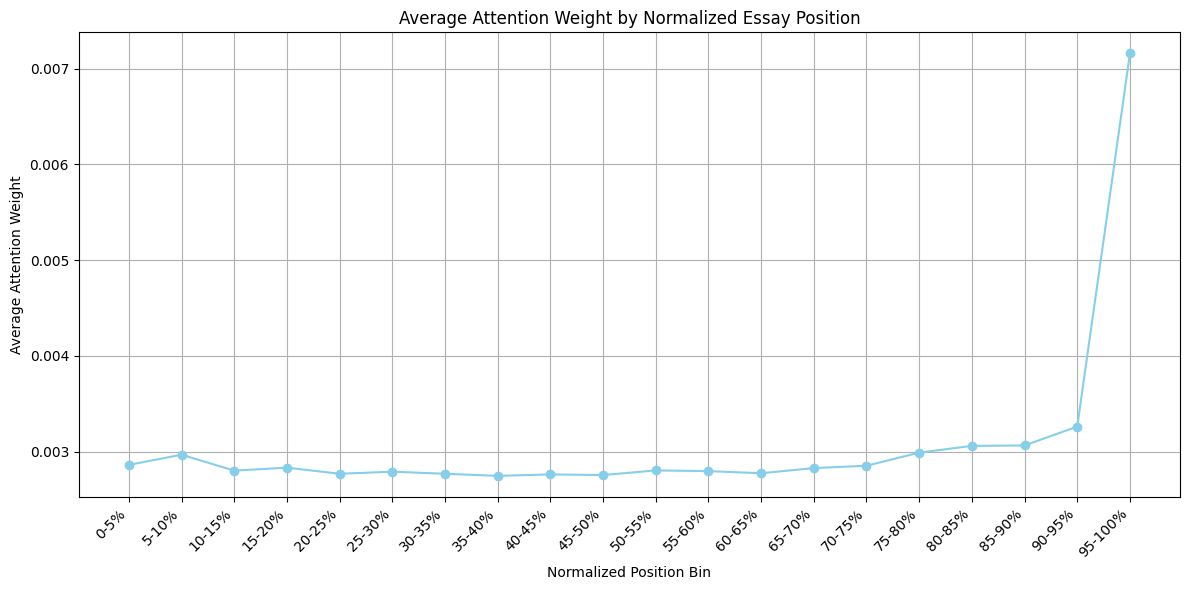

Finished plotting average attention by normalized essay position.


In [42]:
average_position_attention = [
    np.mean(bin_weights) if bin_weights else 0
    for bin_weights in position_attention_bins
]

# Create bin labels for plotting
bin_labels = [f'{i*5}-{(i+1)*5}%' for i in range(NUM_POSITION_BINS)]

# Plot the average attention by normalized position
plt.figure(figsize=(12, 6))
plt.plot(range(NUM_POSITION_BINS), average_position_attention, marker='o', linestyle='-', color='skyblue')
plt.xticks(range(NUM_POSITION_BINS), bin_labels, rotation=45, ha='right')
plt.title('Average Attention Weight by Normalized Essay Position')
plt.xlabel('Normalized Position Bin')
plt.ylabel('Average Attention Weight')
plt.grid(True)
plt.tight_layout()
plt.show()

print("Finished plotting average attention by normalized essay position.")

## Statistical Testing

BiLSTM CV Scores (QWK): [np.float64(0.7732417743742772), np.float64(0.7276725658290986), np.float64(0.7604281308580758), np.float64(0.76050736811159), np.float64(0.7623490718669157)]
Classical ML CV Scores (QWK): [np.float64(0.6947697216610481), np.float64(0.6896396271492986), np.float64(0.6876284113034218), np.float64(0.6918450574282313), np.float64(0.7025060320092302)]
Differences (BiLSTM - Classical ML) per fold: [0.07847205 0.03803294 0.07279972 0.06866231 0.05984304]

Bootstrapped Mean Difference (BiLSTM - Classical ML): 0.0635
95% Confidence Interval for Mean Difference: [0.0505, 0.0742]


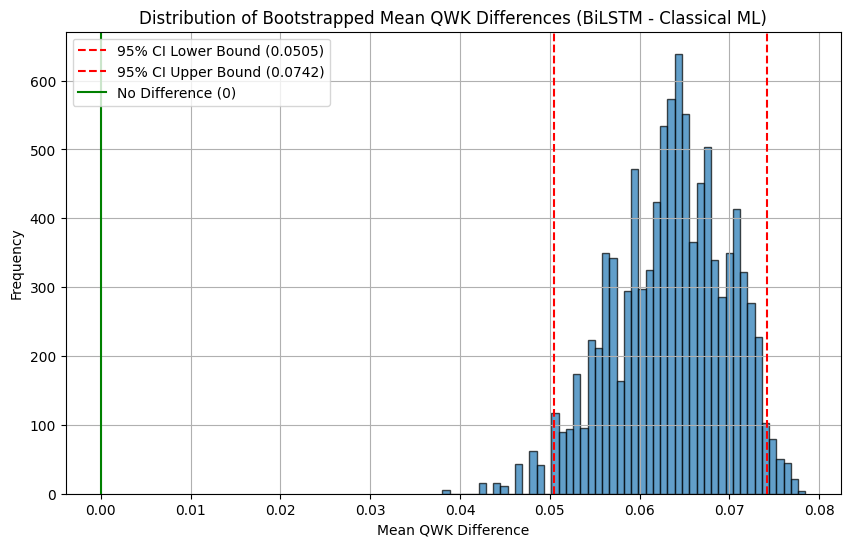


--- Statistical Significance Interpretation ---
The 95% confidence interval is entirely above zero.
This suggests that the BiLSTM model significantly outperforms the Classical ML model (at alpha=0.05).


In [45]:
# 1. Redefine run_cross_validation to return both mean and individual fold scores


# 2. Use the modified function to obtain BiLSTM cross-validation scores
print("BiLSTM CV Scores (QWK):", bilstm_cv_scores)

print("Classical ML CV Scores (QWK):", cv_scores_baseline)

# Ensure both lists have the same length for paired comparison
if len(bilstm_cv_scores) != len(cv_scores_baseline):
    raise ValueError("Number of folds for BiLSTM and Classical ML models do not match.")

# 4. Calculate the QWK difference for each corresponding fold
# A positive difference means BiLSTM performed better
differences = np.array(bilstm_cv_scores) - np.array(cv_scores_baseline)
print("Differences (BiLSTM - Classical ML) per fold:", differences)

# 5. Perform a bootstrap resampling procedure (10,000 samples)
n_bootstraps = 10000
bootstrapped_mean_differences = []

for _ in range(n_bootstraps):
    # Resample the differences with replacement
    resampled_differences = np.random.choice(differences, size=len(differences), replace=True)
    # Calculate the mean of the resampled differences
    bootstrapped_mean_differences.append(np.mean(resampled_differences))

# 6. Construct a 95% confidence interval
alpha = 0.05
lower_bound = np.percentile(bootstrapped_mean_differences, (alpha / 2) * 100)
upper_bound = np.percentile(bootstrapped_mean_differences, (1 - alpha / 2) * 100)

print(f"\nBootstrapped Mean Difference (BiLSTM - Classical ML): {np.mean(bootstrapped_mean_differences):.4f}")
print(f"95% Confidence Interval for Mean Difference: [{lower_bound:.4f}, {upper_bound:.4f}]")

# 7. Plot the distribution of bootstrapped differences
plt.figure(figsize=(10, 6))
plt.hist(bootstrapped_mean_differences, bins=50, edgecolor='k', alpha=0.7)
plt.axvline(lower_bound, color='red', linestyle='--', label=f'95% CI Lower Bound ({lower_bound:.4f})')
plt.axvline(upper_bound, color='red', linestyle='--', label=f'95% CI Upper Bound ({upper_bound:.4f})')
plt.axvline(0, color='green', linestyle='-', label='No Difference (0)')
plt.title('Distribution of Bootstrapped Mean QWK Differences (BiLSTM - Classical ML)')
plt.xlabel('Mean QWK Difference')
plt.ylabel('Frequency')
plt.legend()
plt.grid(True)
plt.show()

# 8. Interpret the results
print("\n--- Statistical Significance Interpretation ---")
if lower_bound > 0:
    print("The 95% confidence interval is entirely above zero.")
    print("This suggests that the BiLSTM model significantly outperforms the Classical ML model (at alpha=0.05).")
elif upper_bound < 0:
    print("The 95% confidence interval is entirely below zero.")
    print("This suggests that the Classical ML model significantly outperforms the BiLSTM model (at alpha=0.05).")
elif lower_bound < 0 and upper_bound > 0:
    print("The 95% confidence interval includes zero.")
    print("This suggests that there is no statistically significant difference in performance between the two models (at alpha=0.05).")
else:
    print("The confidence interval includes zero or is very close to it.")
    print("Further investigation might be needed, but based on this interval, no statistically significant difference is found.")